In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [2]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

# about dataset

In [3]:
#3D variable
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
#First element which is a 28x28 matrix
print(x_train[0].shape)
x_train[0]

(28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [5]:
# output data
print(y_train.shape)
print(y_train[0:5])

(60000,)
[5 0 4 1 9]


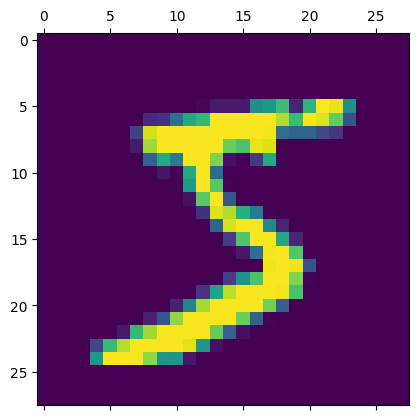

In [6]:
#visualizing the elements
plt.matshow(x_train[0])
plt.show()


# model preprocessing

In [7]:
#flattening the variables (3D to 2D)
x_train_flattened=x_train.reshape(len(x_train),28*28)
x_test_flattened=x_test.reshape(len(x_test),28*28)
print(x_train_flattened.shape)

(60000, 784)


In [8]:
x_train_scaled = x_train_flattened / 255.0 #here 255 is because the pixel values range from 0 to 255
x_test_scaled = x_test_flattened / 255.0

# model creation (ANN - Artificial Neural Network)

In [9]:
model = keras.Sequential()
model.add(keras.layers.Dense(10,input_shape=(784,),activation='sigmoid'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\data science 2025\git_repository\data-science-project-\digit_recognization_CNN\demo\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.fit(x_train_scaled,y_train,epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8775 - loss: 0.4702
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9154 - loss: 0.3035
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9218 - loss: 0.2827
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9234 - loss: 0.2733
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9255 - loss: 0.2665


In [11]:
model.evaluate(x_test_scaled, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9263 - loss: 0.2693


[0.2692810893058777, 0.9262999892234802]

In [12]:
y_pred=model.predict(x_test_scaled)
y_pred.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [13]:
y_pred[0]

array([3.6886740e-02, 4.8875523e-07, 9.8423138e-02, 9.6597028e-01,
       2.8982344e-03, 1.7728586e-01, 2.1074127e-06, 9.9983042e-01,
       1.5486231e-01, 6.9262868e-01], dtype=float32)

In [14]:
# In the output there are ten values (probabilities) for each image those are called ten neurons in output layer we pick the highest probability one
y_pred_int = np.argmax(y_pred,axis=1)# runs column wise and returns index of max value 
print(y_pred_int)

[7 2 1 ... 4 5 6]


Predicted digit y_pred_int: 7
Actual digit y_test_int: 7


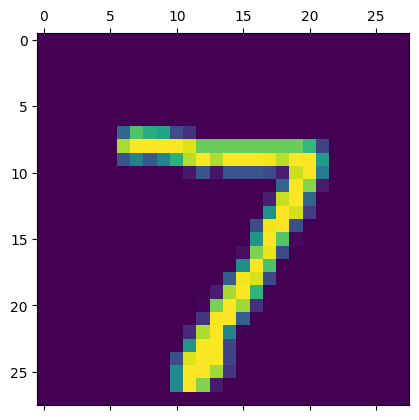

In [15]:
#visualizing the test data
plt.matshow(x_test[0])
print("Predicted digit y_pred_int:", y_pred_int[0])
print("Actual digit y_test_int:", y_test[0])
plt.show()

# Analysis of prediction values

In [16]:
cm=tf.math.confusion_matrix(y_test,y_pred_int)
print(cm)

tf.Tensor(
[[ 967    0    1    2    0    5    2    2    1    0]
 [   0 1110    3    2    0    1    4    2   13    0]
 [   6    8  930   16    7    2   10   11   40    2]
 [   2    0   20  920    0   24    2   11   26    5]
 [   2    1    9    2  907    0    8    5   15   33]
 [  11    2    4   32    5  780   10    4   40    4]
 [  13    3   10    0    7   16  901    2    6    0]
 [   1    6   21    8    5    1    0  950    6   30]
 [   6    6    6   16    8   20    8    8  891    5]
 [  10    6    1   10   25    8    0   27   15  907]], shape=(10, 10), dtype=int32)


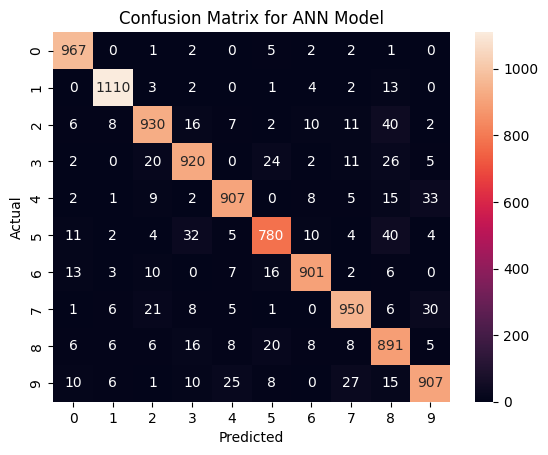

In [17]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for ANN Model')
plt.show()

## DNN-deep neural network to improve the model performance
# Hidden layers(deep learning)

In [18]:
model2=keras.Sequential()
model2.add(keras.layers.Dense(100,input_shape=(784,),activation='relu')) #first hidden layer output 100 neurons
model2.add(keras.layers.Dense(10,activation='sigmoid'))#output layer 10 neurons
model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\data science 2025\git_repository\data-science-project-\digit_recognization_CNN\demo\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model2.fit(x_train_scaled,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9238 - loss: 0.2677
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9658 - loss: 0.1185
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9754 - loss: 0.0831
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9802 - loss: 0.0640
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9849 - loss: 0.0487


In [20]:
model2.evaluate(x_test_scaled, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9743 - loss: 0.0776


[0.07764245569705963, 0.9743000268936157]

In [21]:
y_pred2=model2.predict(x_test_scaled)
y_pred2[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.6251976e-03, 7.4084342e-04, 1.0534648e-01, 9.5206434e-01,
       2.3037712e-06, 2.8798706e-03, 1.9271572e-05, 9.9999052e-01,
       7.9261750e-02, 1.2613057e-01], dtype=float32)

In [22]:
#choosing the max probability one from y_pred
y_pred2_int=np.argmax(y_pred2,axis=1)
y_pred2_int[0]

np.int64(7)

Predicted digit y_pred2_int: 7
Actual digit y_test_int: 7


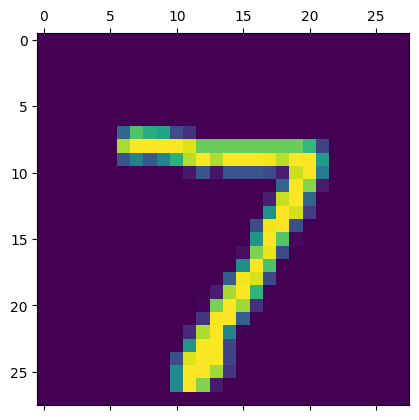

In [23]:
#visualizing the test data for model with hidden layer
plt.matshow(x_test[0])
print("Predicted digit y_pred2_int:", y_pred2_int[0])
print("Actual digit y_test_int:", y_test[0])
plt.show()

In [24]:
cm=tf.math.confusion_matrix(y_test, y_pred2_int)
print(cm)

tf.Tensor(
[[ 966    0    0    0    1    3    5    1    4    0]
 [   0 1128    3    0    0    0    2    0    2    0]
 [   3    3 1009    0    1    1    3    5    7    0]
 [   0    0    9  973    0   10    0    7    4    7]
 [   1    0    2    1  940    0    6    5    3   24]
 [   3    0    0    5    0  869    3    1    4    7]
 [   3    3    1    0    1    7  943    0    0    0]
 [   0    8    6    2    0    0    0 1004    2    6]
 [   5    1    9    5    3    2    4    4  935    6]
 [   1    6    0    4    5    6    0    9    2  976]], shape=(10, 10), dtype=int32)


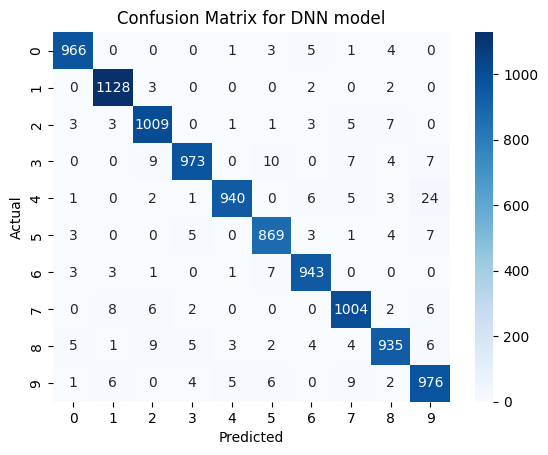

In [25]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix for DNN model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Saving the model for backend use


In [26]:
import pickle
with open('model1.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('model2.pkl', 'wb') as f:
    pickle.dump(model2, f)